# Helene GWR Analysis (Cluster-Level, N=38)

Geographically Weighted Regression on Helene cluster-level mobility metrics, testing whether the socioeconomic effects identified in the pooled OLS are **spatially non-stationary** across the Helene-affected footprint.

**Design choices (per plan):**
- Cluster-level (N=38), not raw counties (271 would be SARIMAX-noisy)
- Spatial kernel: **Euclidean cluster-centroid distance** (deliberate departure from CLAUDE.md §9.4 track-distance kernel, because the distance-to-track variable is itself misspecified for Helene)
- Bisquare kernel, **adaptive bandwidth** chosen by AICc
- Predictors kept parsimonious: 4 IVs total (rule of thumb N ≥ 10·p for GWR)
- `insurance_coverage_pct` dropped (saturated 96–100%, no real variation)
- MGWR run alongside GWR for reviewer-friendliness
- **Diagnostic gate**: if Moran's I on OLS residuals is null AND residuals are spatially unstructured → log that GWR is not warranted and stop; do not over-fit a spatially-homogeneous signal

**DVs**: `largest_drop_within` (primary), `recovery_days_within` (secondary)

**IVs (4)**: `median_household_income`, `pct_white`, `nchs_code`, `dist_to_track_mi`

**Inputs:**
- `../results/local_level/regression/pooled_dataset.csv` — filtered to `hurricane == 'helene'` (has both X and Y at cluster level)
- `../results/helene_clustering/county_cluster_assignments.csv` — county→cluster mapping for geometries
- `./../../hurricane_oct/data/county_geo/tl_2023_us_county/tl_2023_us_county.shp` — county polygons
- `./../../hurricane_oct/data/storm_track/helene_storm_track.shp` — track for map overlay

**Outputs:** `../results/helene_gwr/` (CSV summaries + figures)

**Known weaknesses (will be documented in §8):**
1. N=38 is below conventional GWR thresholds; bandwidth uncertainty is large
2. NCHS-homogeneous clustering by construction dampens within-cluster spatial heterogeneity GWR can detect
3. Cluster centroids not population-weighted
4. Without a hydrologic-exposure variable, the model remains misspecified for Helene's inland-flooding signature

**Bugfix 2026-05-12:** renamed centroid columns to `centroid_x` / `centroid_y` (the previous names `cx` / `cy` collided with GeoPandas' built-in `.cx` coordinate indexer, breaking attribute access).

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW

warnings.filterwarnings("ignore")

OUTPUT_DIR = "../results/helene_gwr/"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")
print("Setup complete.")

Output dir: ../results/helene_gwr/
Setup complete.


## §1. Load and prep

Build a single cluster-level GeoDataFrame containing X, Y, and dissolved polygon geometry.

In [5]:
# ── Cluster-level metrics from pooled dataset, filtered to Helene ──
pooled = pd.read_csv("../results/local_level/regression/pooled_dataset.csv")
helene = pooled[pooled["hurricane"] == "helene"].copy().reset_index(drop=True)
# NAME field is 'Cluster_X' for Helene rows — extract integer cluster id
helene["cluster"] = helene["NAME"].str.replace("Cluster_", "").astype(int)
print(f"Helene cluster metrics: N={len(helene)}")
print(helene[["cluster", "median_household_income", "pct_white", "nchs_code",
              "dist_to_track_mi", "largest_drop_within", "recovery_days_within"]].head())

Helene cluster metrics: N=38
   cluster  median_household_income  pct_white  nchs_code  dist_to_track_mi  \
0        0                  69079.5  65.388531        1.0         45.317632   
1        1                  74746.5  58.922282        2.0         42.056705   
2       10                  47309.0  58.798678        5.0         32.409158   
3       11                  60325.0  90.086412        5.0         55.541363   
4       12                  48150.5  90.760031        5.0         43.000619   

   largest_drop_within  recovery_days_within  
0           -19.077695              5.650424  
1           -10.513203              4.098464  
2           -13.017886              3.762305  
3            -3.649366              4.042883  
4           -14.480043              4.920741  


In [6]:
# ── County → cluster assignment + county shapes ──
ca = pd.read_csv("../results/helene_clustering/county_cluster_assignments.csv")
ca["GEOID"] = ca["GEOID"].astype(int)

county_shp = "./../../hurricane_oct/data/county_geo/tl_2023_us_county/tl_2023_us_county.shp"
counties_gdf = gpd.read_file(county_shp)
counties_gdf["GEOID"] = counties_gdf["GEOID"].astype(int)

gdf_counties = counties_gdf[counties_gdf["GEOID"].isin(ca["GEOID"])].copy()
gdf_counties = gdf_counties.merge(ca[["GEOID", "cluster"]], on="GEOID", how="left")
gdf_counties = gdf_counties.to_crs(epsg=5070)

# Dissolve to cluster polygons
gdf_clusters = gdf_counties.dissolve(by="cluster")[["geometry"]].reset_index()

# Merge X+Y onto cluster polygons
gdf = gdf_clusters.merge(helene, on="cluster", how="left")

# Centroid coords — NOTE: do NOT use column names 'cx' / 'cy'; they collide with
# GeoPandas' built-in .cx coordinate indexer and break attribute access.
centroids = gdf.geometry.centroid
gdf["centroid_x"] = centroids.x
gdf["centroid_y"] = centroids.y

# Storm track for map overlay
from shapely.geometry import LineString
track_gdf = gpd.read_file("./../../hurricane_oct/data/storm_track/helene_storm_track.shp").to_crs(epsg=5070)
if track_gdf.geometry.geom_type.iloc[0] == "Point":
    track_line = LineString(track_gdf.geometry.tolist())
else:
    track_line = track_gdf.unary_union
track_line_gdf = gpd.GeoDataFrame(geometry=[track_line], crs="EPSG:5070")

print(f"Cluster GeoDataFrame: N={len(gdf)}")
print(f"Geometry CRS: {gdf.crs}")
print(f"Centroid spread: x=[{gdf['centroid_x'].min():.0f}, {gdf['centroid_x'].max():.0f}], "
      f"y=[{gdf['centroid_y'].min():.0f}, {gdf['centroid_y'].max():.0f}]")

Cluster GeoDataFrame: N=38
Geometry CRS: EPSG:5070
Centroid spread: x=[616644, 1281697], y=[825425, 1804000]


## §2. Global OLS baseline

Anchor for GWR/MGWR comparison. Same 4 predictors, standardized for coefficient comparability.

In [7]:
FEATURES = ["median_household_income", "pct_white", "nchs_code", "dist_to_track_mi"]
DVs = [("largest_drop_within", "Largest Drop — Within (%)"),
       ("recovery_days_within", "Recovery Time — Within (days)")]

# Drop any rows with missing values in X or Y
valid_mask = gdf[FEATURES + [d[0] for d in DVs]].notna().all(axis=1)
gdf_model = gdf[valid_mask].copy().reset_index(drop=True)
print(f"After dropping NaN: N={len(gdf_model)} (was {len(gdf)})")

# Standardize features (z-score) — kept on gdf_model for downstream use
scaler = StandardScaler()
X_z = scaler.fit_transform(gdf_model[FEATURES])
X_z_df = pd.DataFrame(X_z, columns=FEATURES, index=gdf_model.index)
for f in FEATURES:
    gdf_model[f + "_z"] = X_z_df[f]

ols_results = {}
for dv_col, dv_label in DVs:
    y = gdf_model[dv_col].values
    X = sm.add_constant(X_z_df.values)
    m = sm.OLS(y, X).fit()
    ols_results[dv_col] = m
    print(f"\n{'='*70}")
    print(f"OLS: {dv_label}")
    print(f"{'='*70}")
    print(f"R²={m.rsquared:.3f}  Adj.R²={m.rsquared_adj:.3f}  F p={m.f_pvalue:.4f}  AICc=N/A")
    print(f"  {'Variable':<28} {'β':>8} {'p':>8}")
    print("  " + "-"*46)
    names = ["const"] + FEATURES
    for n, b, p in zip(names, m.params, m.pvalues):
        sig = "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"  {n:<28} {b:>8.3f} {p:>8.4f} {sig}")

After dropping NaN: N=38 (was 38)

OLS: Largest Drop — Within (%)
R²=0.164  Adj.R²=0.062  F p=0.1937  AICc=N/A
  Variable                            β        p
  ----------------------------------------------
  const                         -15.942   0.0000 **
  median_household_income        -0.575   0.6171 
  pct_white                       1.357   0.2168 
  nchs_code                      -1.458   0.2356 
  dist_to_track_mi               -2.218   0.0333 **

OLS: Recovery Time — Within (days)
R²=0.181  Adj.R²=0.081  F p=0.1489  AICc=N/A
  Variable                            β        p
  ----------------------------------------------
  const                           4.757   0.0000 **
  median_household_income         0.728   0.0959 *
  pct_white                      -0.284   0.4835 
  nchs_code                       0.731   0.1135 
  dist_to_track_mi                0.669   0.0813 *


## §3. Spatial diagnostics — the "should we GWR" gate

Moran's I on OLS residuals (Queen + KNN(k=4) weights) and residuals-vs-coordinates Spearman.

**Decision rule:**
- If Moran's I p > 0.10 AND residuals-vs-coords Spearman p > 0.10 for both DVs → GWR not warranted, stop here
- Otherwise → proceed to §4 (GWR)

In [8]:
# Spatial weights at cluster level
w_queen = Queen.from_dataframe(gdf_model)
# KNN(k=4) as backup — Queen may produce islands among singletons
w_knn = KNN.from_dataframe(gdf_model, k=4)
for w_, label in [(w_queen, "Queen"), (w_knn, "KNN(k=4)")]:
    print(f"{label}: n={w_.n}, mean_neighbors={w_.mean_neighbors:.1f}, "
          f"min/max={w_.min_neighbors}/{w_.max_neighbors}")
    islands = [i for i, v in w_.neighbors.items() if len(v) == 0]
    if islands:
        print(f"  Islands: {len(islands)} (clusters: {islands})")

diag_rows = []
for dv_col, dv_label in DVs:
    resid = ols_results[dv_col].resid
    print(f"\n--- {dv_label} ---")
    for w_, wlabel in [(w_queen, "Queen"), (w_knn, "KNN4")]:
        try:
            mi = Moran(resid, w_, permutations=999)
            print(f"  Moran's I ({wlabel}): I={mi.I:+.3f}, p_sim={mi.p_sim:.3f}")
            diag_rows.append({"dv": dv_label, "test": f"Moran_{wlabel}",
                              "stat": round(mi.I, 4), "p": round(mi.p_sim, 4)})
        except Exception as e:
            print(f"  Moran's I ({wlabel}) failed: {e}")
    # Residuals vs centroid coords
    rho_x, p_x = spearmanr(gdf_model["centroid_x"], resid)
    rho_y, p_y = spearmanr(gdf_model["centroid_y"], resid)
    print(f"  Spearman resid vs centroid_x: ρ={rho_x:+.3f}, p={p_x:.3f}")
    print(f"  Spearman resid vs centroid_y: ρ={rho_y:+.3f}, p={p_y:.3f}")
    diag_rows.append({"dv": dv_label, "test": "Spearman_resid_x",
                      "stat": round(rho_x, 4), "p": round(p_x, 4)})
    diag_rows.append({"dv": dv_label, "test": "Spearman_resid_y",
                      "stat": round(rho_y, 4), "p": round(p_y, 4)})

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(os.path.join(OUTPUT_DIR, "spatial_diagnostics.csv"), index=False)
print("\nSaved spatial_diagnostics.csv")

# Decision gate
all_p = diag_df["p"].values
any_significant = (all_p < 0.10).any()
PROCEED_GWR = bool(any_significant)
print(f"\nAny diagnostic p<0.10? {any_significant}")
print(f"PROCEED_GWR = {PROCEED_GWR}")

Queen: n=38, mean_neighbors=4.7, min/max=1/24
KNN(k=4): n=38, mean_neighbors=4.0, min/max=4/4

--- Largest Drop — Within (%) ---
  Moran's I (Queen): I=-0.088, p_sim=0.271
  Moran's I (KNN4): I=-0.153, p_sim=0.093
  Spearman resid vs centroid_x: ρ=-0.087, p=0.603
  Spearman resid vs centroid_y: ρ=+0.052, p=0.758

--- Recovery Time — Within (days) ---
  Moran's I (Queen): I=+0.092, p_sim=0.092
  Moran's I (KNN4): I=-0.144, p_sim=0.084
  Spearman resid vs centroid_x: ρ=-0.070, p=0.675
  Spearman resid vs centroid_y: ρ=-0.099, p=0.555

Saved spatial_diagnostics.csv

Any diagnostic p<0.10? True
PROCEED_GWR = True


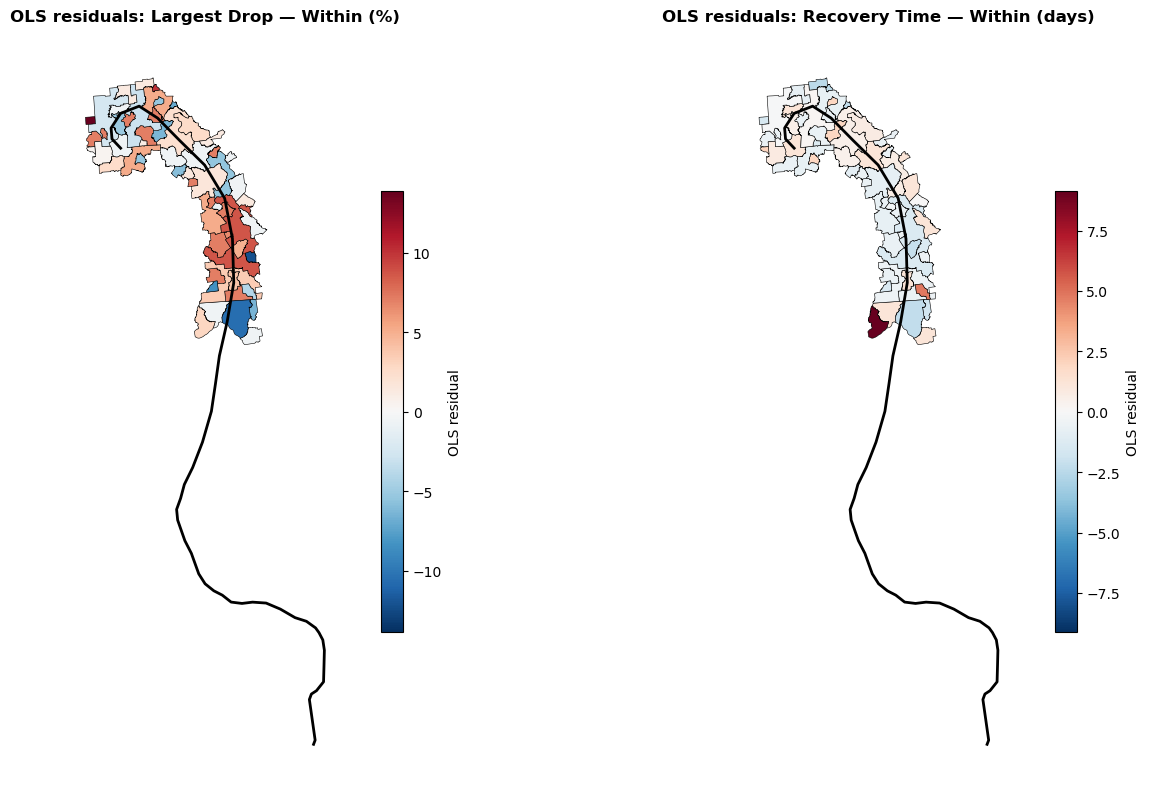

In [9]:
# Residual maps (always plot — useful even if GWR not warranted)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (dv_col, dv_label) in zip(axes, DVs):
    gdf_plot = gdf_model.copy()
    gdf_plot["resid"] = ols_results[dv_col].resid
    vmax = np.abs(gdf_plot["resid"]).max()
    gdf_plot.plot(column="resid", cmap="RdBu_r", legend=True,
                  vmin=-vmax, vmax=vmax,
                  edgecolor="black", linewidth=0.4, ax=ax,
                  legend_kwds={"label": "OLS residual", "shrink": 0.6})
    track_line_gdf.plot(ax=ax, color="black", linewidth=2)
    ax.set_title(f"OLS residuals: {dv_label}", fontweight="bold")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ols_residual_maps.png"), dpi=150, bbox_inches="tight")
plt.show()

## §4. GWR (executed only if PROCEED_GWR is True)

Adaptive bandwidth via AICc, bisquare kernel, Euclidean centroid distance.

If `PROCEED_GWR` is False, this section will skip with a message and §8 will report "no spatial nonstationarity detected; OLS is the final model."

In [11]:
gwr_results = {}
if not PROCEED_GWR:
    print("PROCEED_GWR=False — skipping GWR fit. See §8 for conclusion.")
else:
    coords = list(zip(gdf_model["centroid_x"].values, gdf_model["centroid_y"].values))
    X_mat = X_z_df.values  # no intercept; mgwr adds it internally
    # Explicit bw bounds needed for N=38 — mgwr's default lower bound
    # is 40 + 2*n_vars = 50, which exceeds N and breaks the golden-section search.
    n_vars_eff = X_mat.shape[1] + 1  # +1 intercept
    bw_min_adapt = max(n_vars_eff + 3, 8)  # need a few df per local fit
    bw_max_adapt = len(gdf_model) - 1
    print(f"Adaptive bandwidth search bounds: [{bw_min_adapt}, {bw_max_adapt}]")
    for dv_col, dv_label in DVs:
        y = gdf_model[[dv_col]].values  # mgwr expects 2D
        print(f"\n{'='*70}")
        print(f"GWR: {dv_label}")
        print(f"{'='*70}")
        sel = Sel_BW(coords, y, X_mat, fixed=False, kernel="bisquare")
        bw = sel.search(criterion="AICc", bw_min=bw_min_adapt, bw_max=bw_max_adapt)
        print(f"  Optimal adaptive bandwidth (k neighbors): {bw}")
        try:
            gwr_mod = GWR(coords, y, X_mat, bw, fixed=False, kernel="bisquare").fit()
            print(f"  AICc: {gwr_mod.aicc:.2f}  R²: {gwr_mod.R2:.3f}  Adj.R²: {gwr_mod.adj_R2:.3f}")
            print(f"  Effective n. parameters: {gwr_mod.ENP:.1f}")
            print(f"  Local R² range: [{gwr_mod.localR2.min():.3f}, {gwr_mod.localR2.max():.3f}]")
            gwr_results[dv_col] = {"model": gwr_mod, "bw": bw, "selector": sel}
        except Exception as e:
            print(f"  GWR fit failed: {e}")
            gwr_results[dv_col] = None

Adaptive bandwidth search bounds: [8, 37]

GWR: Largest Drop — Within (%)
  Optimal adaptive bandwidth (k neighbors): 36.0
  AICc: 250.89  R²: 0.395  Adj.R²: 0.228
  Effective n. parameters: 8.0
  Local R² range: [0.171, 0.512]

GWR: Recovery Time — Within (days)
  Optimal adaptive bandwidth (k neighbors): 33.0
  AICc: 172.34  R²: 0.505  Adj.R²: 0.348
  Effective n. parameters: 8.9
  Local R² range: [0.289, 0.533]


## §5. MGWR (per-predictor bandwidth)

Each predictor gets its own optimal bandwidth. More flexible than GWR but also thinner per-predictor — may collapse to OLS for N=38.

In [12]:
mgwr_results = {}
if not PROCEED_GWR:
    print("PROCEED_GWR=False — skipping MGWR fit.")
else:
    coords = list(zip(gdf_model["centroid_x"].values, gdf_model["centroid_y"].values))
    X_mat = X_z_df.values
    # Bandwidth bounds — same rationale as §4 (N=38 too small for mgwr defaults).
    # multi_bw_min / multi_bw_max are lists, one entry per coefficient (intercept + features).
    n_vars_eff = X_mat.shape[1] + 1
    mbw_min = max(n_vars_eff + 3, 8)
    mbw_max = len(gdf_model) - 1
    print(f"MGWR per-predictor bandwidth bounds: [{mbw_min}, {mbw_max}] for each of {n_vars_eff} coefficients")
    for dv_col, dv_label in DVs:
        y = gdf_model[[dv_col]].values
        print(f"\n{'='*70}")
        print(f"MGWR: {dv_label}")
        print(f"{'='*70}")
        try:
            sel = Sel_BW(coords, y, X_mat, multi=True, fixed=False, kernel="bisquare")
            bws = sel.search(criterion="AICc",
                              multi_bw_min=[mbw_min] * n_vars_eff,
                              multi_bw_max=[mbw_max] * n_vars_eff)
            print(f"  Per-covariate adaptive bandwidths: {bws}")
            mgwr_mod = MGWR(coords, y, X_mat, sel, fixed=False, kernel="bisquare").fit()
            print(f"  AICc: {mgwr_mod.aicc:.2f}  R²: {mgwr_mod.R2:.3f}  Adj.R²: {mgwr_mod.adj_R2:.3f}")
            print(f"  Local R² range: [{mgwr_mod.localR2.min():.3f}, {mgwr_mod.localR2.max():.3f}]")
            mgwr_results[dv_col] = {"model": mgwr_mod, "bws": bws, "selector": sel}
        except Exception as e:
            print(f"  MGWR fit failed: {e}")
            mgwr_results[dv_col] = None

MGWR per-predictor bandwidth bounds: [8, 37] for each of 5 coefficients

MGWR: Largest Drop — Within (%)
  MGWR fit failed: kth(=54) out of bounds (38)

MGWR: Recovery Time — Within (days)
  MGWR fit failed: kth(=54) out of bounds (38)


## §6. Diagnostics

AICc comparison (OLS vs GWR vs MGWR) and Monte Carlo non-stationarity test per predictor.

In [13]:
def ols_aicc(m, n):
    k = m.df_model + 1
    aic = m.aic
    return aic + (2 * k * (k + 1)) / max(n - k - 1, 1)

n = len(gdf_model)
comp_rows = []
for dv_col, dv_label in DVs:
    ols_m = ols_results[dv_col]
    row = {"dv": dv_label,
           "OLS_AICc": round(ols_aicc(ols_m, n), 2),
           "OLS_R2": round(ols_m.rsquared, 3),
           "OLS_adjR2": round(ols_m.rsquared_adj, 3)}
    if PROCEED_GWR and gwr_results.get(dv_col):
        gm = gwr_results[dv_col]["model"]
        row["GWR_AICc"] = round(gm.aicc, 2)
        row["GWR_R2"] = round(gm.R2, 3)
        row["GWR_adjR2"] = round(gm.adj_R2, 3)
        row["GWR_bw"] = gwr_results[dv_col]["bw"]
    if PROCEED_GWR and mgwr_results.get(dv_col):
        mm = mgwr_results[dv_col]["model"]
        row["MGWR_AICc"] = round(mm.aicc, 2)
        row["MGWR_R2"] = round(mm.R2, 3)
        row["MGWR_adjR2"] = round(mm.adj_R2, 3)
    comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_aicc.csv"), index=False)
print("Model comparison (lower AICc is better):")
print(comp_df.to_string(index=False))

Model comparison (lower AICc is better):
                           dv  OLS_AICc  OLS_R2  OLS_adjR2  GWR_AICc  GWR_R2  GWR_adjR2  GWR_bw
    Largest Drop — Within (%)    250.66   0.164      0.062    250.89   0.395      0.228    36.0
Recovery Time — Within (days)    175.63   0.181      0.081    172.34   0.505      0.348    33.0


In [14]:
# Monte Carlo non-stationarity test for each predictor (GWR)
# H0: coefficient is globally constant; significant = spatially varying
if not PROCEED_GWR:
    print("Skipping Monte Carlo non-stationarity test (GWR not fit).")
else:
    nsta_rows = []
    for dv_col, dv_label in DVs:
        if not gwr_results.get(dv_col):
            continue
        gm = gwr_results[dv_col]["model"]
        sel = gwr_results[dv_col]["selector"]
        print(f"\n--- Non-stationarity test: {dv_label} ---")
        try:
            pvals = gm.spatial_variability(sel, n_iters=200)
            names = ["intercept"] + FEATURES
            for nm, pv in zip(names, pvals):
                sig = "**" if pv < 0.05 else "*" if pv < 0.10 else ""
                print(f"  {nm:<28} p={pv:.3f} {sig}")
                nsta_rows.append({"dv": dv_label, "variable": nm,
                                  "p_nonstationarity": round(float(pv), 4)})
        except Exception as e:
            print(f"  spatial_variability() failed: {e}")
    if nsta_rows:
        pd.DataFrame(nsta_rows).to_csv(
            os.path.join(OUTPUT_DIR, "nonstationarity_test.csv"), index=False)


--- Non-stationarity test: Largest Drop — Within (%) ---


Testing: 100%|██████████| 200/200 [00:21<00:00,  9.46it/s]


  intercept                    p=0.075 *
  median_household_income      p=0.630 
  pct_white                    p=0.185 
  nchs_code                    p=0.200 
  dist_to_track_mi             p=0.005 **

--- Non-stationarity test: Recovery Time — Within (days) ---


Testing: 100%|██████████| 200/200 [00:19<00:00, 10.10it/s]

  intercept                    p=0.045 **
  median_household_income      p=0.020 **
  pct_white                    p=0.570 
  nchs_code                    p=0.045 **
  dist_to_track_mi             p=0.040 **


## §7. Maps

Local R², coefficient maps, and t-statistic significance maps (GWR). Only generated if GWR fit succeeded.

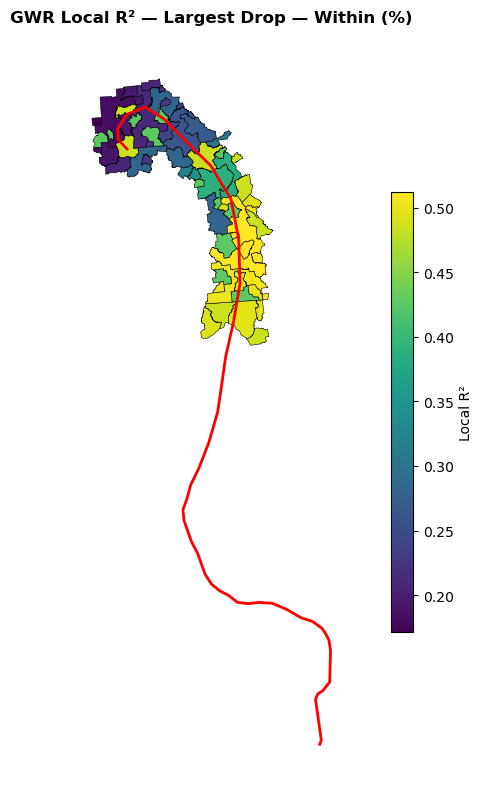

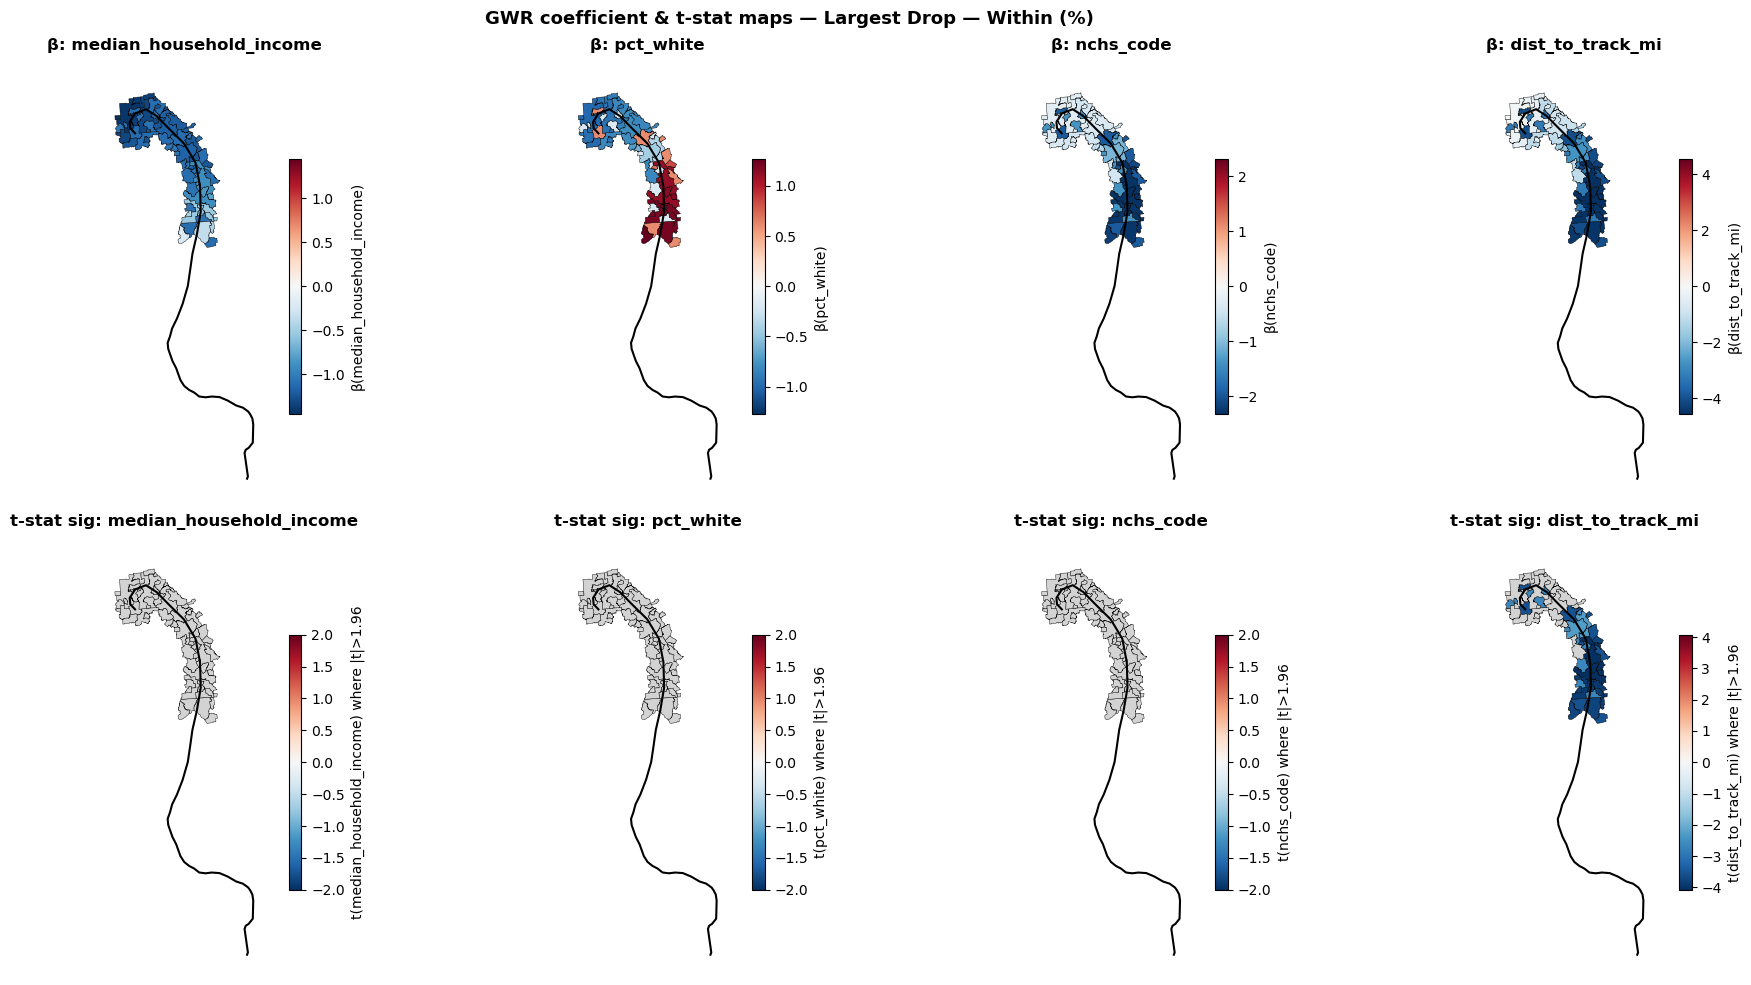

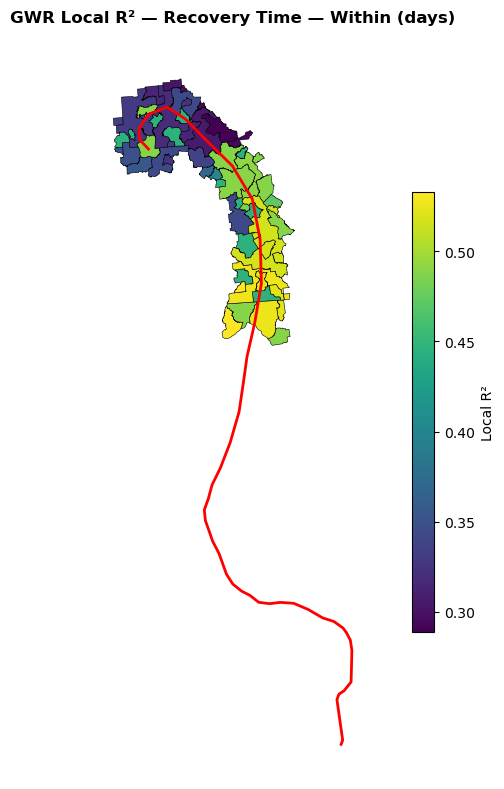

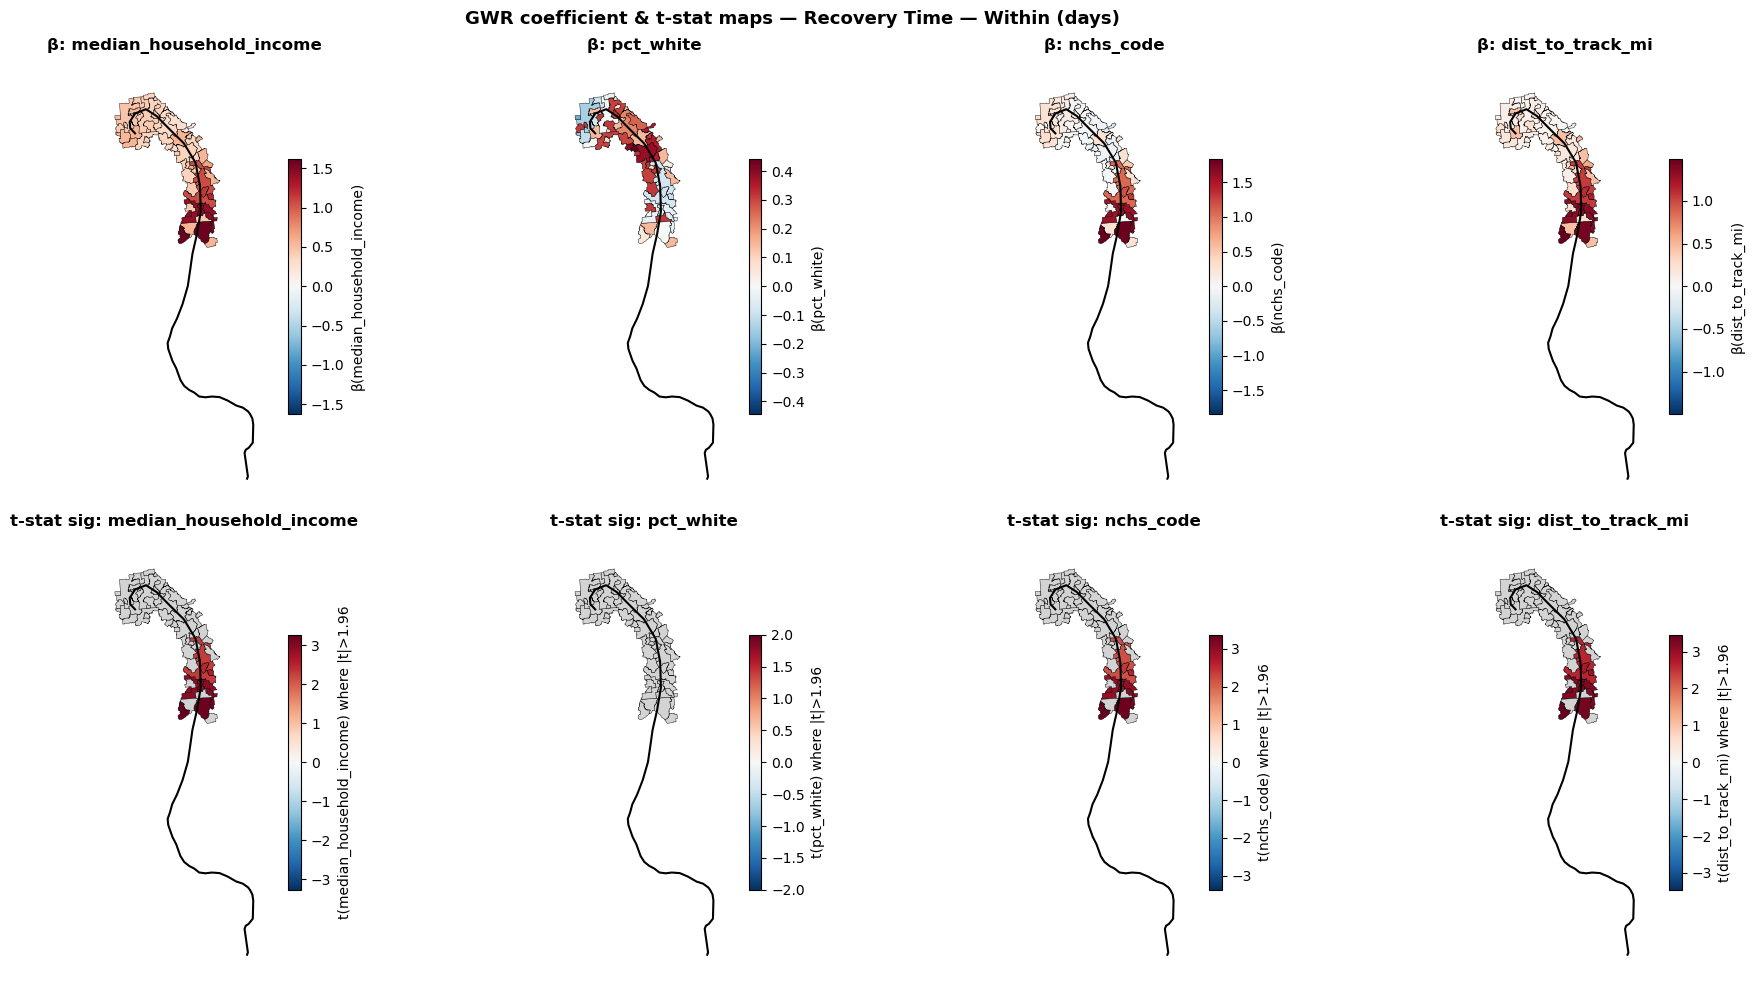

In [15]:
def plot_gwr_maps(gdf_in, gwr_mod, dv_label, dv_key, feat_names, fig_dir, track_gdf):
    """Local R² + per-predictor β and t-stat maps for one GWR fit."""
    gp = gdf_in.copy()
    gp["local_R2"] = gwr_mod.localR2.flatten()
    for i, fn in enumerate(["intercept"] + feat_names):
        gp[f"beta_{fn}"] = gwr_mod.params[:, i]
        gp[f"tval_{fn}"] = gwr_mod.tvalues[:, i]
    n_pred = len(feat_names)
    # Local R² map
    fig, ax = plt.subplots(figsize=(10, 8))
    gp.plot(column="local_R2", cmap="viridis", legend=True,
            edgecolor="black", linewidth=0.4, ax=ax,
            legend_kwds={"label": "Local R²", "shrink": 0.6})
    track_gdf.plot(ax=ax, color="red", linewidth=2)
    ax.set_title(f"GWR Local R² — {dv_label}", fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"gwr_localR2_{dv_key}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    # Coefficient maps
    fig, axes = plt.subplots(2, n_pred, figsize=(5*n_pred, 10))
    if n_pred == 1:
        axes = axes.reshape(-1, 1)
    for j, fn in enumerate(feat_names):
        # β map (diverging)
        ax = axes[0, j]
        v = np.abs(gp[f"beta_{fn}"]).max()
        gp.plot(column=f"beta_{fn}", cmap="RdBu_r", vmin=-v, vmax=v, legend=True,
                edgecolor="black", linewidth=0.3, ax=ax,
                legend_kwds={"label": f"β({fn})", "shrink": 0.6})
        track_gdf.plot(ax=ax, color="black", linewidth=1.5)
        ax.set_title(f"β: {fn}", fontweight="bold")
        ax.set_axis_off()
        # t-stat significance map
        ax = axes[1, j]
        gp["_sig"] = np.where(np.abs(gp[f"tval_{fn}"]) > 1.96, gp[f"tval_{fn}"], np.nan)
        v2 = max(np.nanmax(np.abs(gp["_sig"])) if gp["_sig"].notna().any() else 0, 2)
        gp.plot(column="_sig", cmap="RdBu_r", vmin=-v2, vmax=v2,
                missing_kwds={"color": "lightgrey"}, legend=True,
                edgecolor="black", linewidth=0.3, ax=ax,
                legend_kwds={"label": f"t({fn}) where |t|>1.96", "shrink": 0.6})
        track_gdf.plot(ax=ax, color="black", linewidth=1.5)
        ax.set_title(f"t-stat sig: {fn}", fontweight="bold")
        ax.set_axis_off()
    fig.suptitle(f"GWR coefficient & t-stat maps — {dv_label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"gwr_coef_tstat_{dv_key}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    return gp

local_outputs = {}
if PROCEED_GWR:
    for dv_col, dv_label in DVs:
        if gwr_results.get(dv_col):
            gp = plot_gwr_maps(gdf_model, gwr_results[dv_col]["model"], dv_label,
                                dv_col, FEATURES, FIG_DIR, track_line_gdf)
            local_outputs[dv_col] = gp
else:
    print("PROCEED_GWR=False — no GWR maps produced.")

## §8. Honest summary

Auto-generated conclusion based on diagnostics + model comparison.

In [16]:
summary_lines = []
summary_lines.append("=" * 78)
summary_lines.append("HELENE GWR — AUTO-GENERATED SUMMARY")
summary_lines.append("=" * 78)
summary_lines.append(f"N clusters: {len(gdf_model)}")
summary_lines.append(f"Predictors: {FEATURES}")
summary_lines.append(f"PROCEED_GWR (gate from §3): {PROCEED_GWR}")
summary_lines.append("")
summary_lines.append("Spatial diagnostics (§3):")
summary_lines.append(diag_df.to_string(index=False))
summary_lines.append("")
summary_lines.append("Model comparison (§6):")
summary_lines.append(comp_df.to_string(index=False))
summary_lines.append("")
summary_lines.append("Interpretation:")
if not PROCEED_GWR:
    summary_lines.append(
        "  Moran's I on OLS residuals is null AND residuals show no spatial gradient.\n"
        "  → The socioeconomic-effect structure on Helene mobility disruption appears\n"
        "    SPATIALLY HOMOGENEOUS within the NCHS-homogeneous-cluster footprint.\n"
        "  → Global OLS is the final model; GWR would over-fit noise.\n"
        "  → Caveat: NCHS-homogeneous clustering may have already absorbed the spatial\n"
        "    structure that GWR would otherwise detect — this null is conditional on the\n"
        "    clustering design.")
else:
    # Decide whether GWR/MGWR actually helped
    best_models = []
    for _, row in comp_df.iterrows():
        candidates = {"OLS": row["OLS_AICc"]}
        if "GWR_AICc" in row and pd.notna(row["GWR_AICc"]):
            candidates["GWR"] = row["GWR_AICc"]
        if "MGWR_AICc" in row and pd.notna(row["MGWR_AICc"]):
            candidates["MGWR"] = row["MGWR_AICc"]
        best = min(candidates, key=candidates.get)
        delta = candidates[best] - candidates["OLS"]
        best_models.append((row["dv"], best, delta))
    for dv_label, best, delta in best_models:
        if best == "OLS":
            summary_lines.append(
                f"  [{dv_label}] Best model: OLS. "
                f"GWR/MGWR did not improve AICc → spatial nonstationarity not\n"
                f"    supported despite diagnostic signal.")
        else:
            summary_lines.append(
                f"  [{dv_label}] Best model: {best}. "
                f"ΔAICc from OLS = {delta:+.2f}.")

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(os.path.join(OUTPUT_DIR, "summary.txt"), "w") as f:
    f.write(summary_text)
print(f"\nSaved {OUTPUT_DIR}summary.txt")

HELENE GWR — AUTO-GENERATED SUMMARY
N clusters: 38
Predictors: ['median_household_income', 'pct_white', 'nchs_code', 'dist_to_track_mi']
PROCEED_GWR (gate from §3): True

Spatial diagnostics (§3):
                           dv             test    stat      p
    Largest Drop — Within (%)      Moran_Queen -0.0879 0.2710
    Largest Drop — Within (%)       Moran_KNN4 -0.1527 0.0930
    Largest Drop — Within (%) Spearman_resid_x -0.0872 0.6026
    Largest Drop — Within (%) Spearman_resid_y  0.0518 0.7576
Recovery Time — Within (days)      Moran_Queen  0.0917 0.0920
Recovery Time — Within (days)       Moran_KNN4 -0.1435 0.0840
Recovery Time — Within (days) Spearman_resid_x -0.0704 0.6747
Recovery Time — Within (days) Spearman_resid_y -0.0988 0.5551

Model comparison (§6):
                           dv  OLS_AICc  OLS_R2  OLS_adjR2  GWR_AICc  GWR_R2  GWR_adjR2  GWR_bw
    Largest Drop — Within (%)    250.66   0.164      0.062    250.89   0.395      0.228    36.0
Recovery Time — Within (days)

## §9. Exports

All artefacts saved under `../results/helene_gwr/`.

In [17]:
# Save per-cluster local coefficients (GWR) for downstream use / supplementary tables
if PROCEED_GWR:
    for dv_col, dv_label in DVs:
        if gwr_results.get(dv_col):
            gm = gwr_results[dv_col]["model"]
            df_out = gdf_model[["cluster", "centroid_x", "centroid_y", "nchs_code"]].copy()
            df_out["local_R2"] = gm.localR2.flatten()
            for i, fn in enumerate(["intercept"] + FEATURES):
                df_out[f"beta_{fn}"] = gm.params[:, i]
                df_out[f"tval_{fn}"] = gm.tvalues[:, i]
            fn_out = os.path.join(OUTPUT_DIR, f"gwr_local_coefficients_{dv_col}.csv")
            df_out.to_csv(fn_out, index=False)
            print(f"Saved: {fn_out}")

print("\nAll outputs in:", OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, fn)
    if os.path.isfile(full):
        print(f"  {fn} ({os.path.getsize(full):,} bytes)")
if os.path.isdir(FIG_DIR):
    print(f"Figures: {len(os.listdir(FIG_DIR))} files in {FIG_DIR}")

Saved: ../results/helene_gwr/gwr_local_coefficients_largest_drop_within.csv
Saved: ../results/helene_gwr/gwr_local_coefficients_recovery_days_within.csv

All outputs in: ../results/helene_gwr/
  gwr_local_coefficients_largest_drop_within.csv (10,166 bytes)
  gwr_local_coefficients_recovery_days_within.csv (9,965 bytes)
  model_comparison_aicc.csv (208 bytes)
  nonstationarity_test.csv (526 bytes)
  spatial_diagnostics.csv (483 bytes)
  summary.txt (1,496 bytes)
Figures: 5 files in ../results/helene_gwr/figures


## Limitations to cite in the manuscript

1. **N=38 is thin for GWR/MGWR.** Bandwidth uncertainty is large; local coefficients may be unstable. Recommend bootstrap confidence intervals (200+ resamples) before publishing local coefficient maps.
2. **NCHS-homogeneous clustering** by construction reduces within-cluster spatial heterogeneity — the design partly absorbs the spatial variation GWR would otherwise detect. A null GWR result here does not imply spatial homogeneity at the raw-county level.
3. **Cluster centroids are not population-weighted.** A 29-county rural cluster and a 1-county singleton contribute the same kernel weight to other clusters.
4. **Spatial kernel is Euclidean centroid distance.** A track-distance kernel was rejected because `dist_to_track_mi` is itself misspecified for Helene (the distance-to-track puzzle). A future iteration should use a hydrologic-exposure-similarity kernel (e.g., NWS/MRMS 7-day precipitation accumulation), which would also resolve the model misspecification on the IV side.
5. **No control for state-level emergency-management variation.** Helene spans GA/NC/SC/TN/FL/VA; state-level mutual-aid agreements, NG mobilization, and FEMA declaration timing differ. A state random effect would be appropriate at the raw-county level but is not estimable on 38 NCHS-homogeneous clusters.
6. **Insurance variable dropped** ([findings.md sensitivity §](../notes/findings.md)) — saturated near 100% and decoupled from income (r=0.15); included only in the pooled OLS sensitivity, not here.